## **Import libraries**

In [1]:
import os
import random

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd

from natsort import natsorted

import torch
import torch.nn as nn
from transformers import set_seed as transformers_set_seed

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    DOCXToJSONSConfig,
    LLMConfig
)

from SARVI.data_io.reader import (
    textwrap,
    read_txt_list, read_ann_list,
    read_json_single,
    read_excel_single
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    tokenizer_ner, model_ner
)
from SARVI.services.common.att_funcs import (
    initialize_att_model, remap_att_attribute_labels, undersample_att_negatives
)
from SARVI.services.sync_funcs.att_funcs import(
    prepare_data as prepare_data_SYNC,
    construct_loader_att as construct_loader_att_SYNC,
    run_att_classifier as run_att_classifier_SYNC
)

from SARVI.services.async_funcs.llm_funcs import (
    asyncio
)

from SARVI.models.losses import MoMLoss

from SARVI.data_io.writing import (
    write_torch_checkpoint, write_json_extra_docs, write_parquet
)

WARNING 06-07 14:54:25 [config.py:70] Support for Transformers v4 is deprecated. The Transformers v4 codepath will become unmaintained in vLLM v0.22.0 and will be removed in vLLM v0.24.0. Please upgrade to Transformers v5: pip install --upgrade transformers


Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: PipelineContext):
    print("0. Initializing variables\n")
    # create_intermediate_folder_name(ctx)

    #################################################################################################################

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())
    
    if ctx.ussage == "generative":
        llm = load_llm(ctx.llm_config)
        prompt = textwrap.dedent(prompts_total["report_to_data"])
        modelo_ner = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        icd10_thresholds = None
    else:
        llm = None
        prompt = None
        modelo_ner = [None, None]
        node_list = load_tree_hierarchical_module(df_reference)

        root = node_list["root"]
        root.set_indexes()
        label2id_hs = {key.name: value for key, value in root.node_to_id.items()}
        id2label_hs = {value: key for key, value in label2id_hs.items()}
        label2id_no_hs = {id2label_hs[value.item()]: i for i, value in enumerate(root.leaf_indexes)}
        id2label_no_hs = {value: key for key, value in label2id_no_hs.items()}
        label2id_ICD10 = [label2id_hs, label2id_no_hs]
        id2label_ICD10 = [id2label_hs, id2label_no_hs]
        id_no_hs_to_id_hs = {id_no_hs: label2id_hs[label_name] for label_name, id_no_hs in label2id_no_hs.items()}

        # modelo_icd10_head = [initialize_icd10_hs_head_model(ctx, "ICD10_HS_checkpoint.pt", root), initialize_icd10_no_hs_head_model(ctx, "ICD10_NO_HS_checkpoint.pt", label2id_no_hs, root)]
        # modelo_icd10_prediction = [initialize_icd10_hs_prediction_model(ctx, "ICD10_HS_checkpoint.pt", label2id_hs, root), None]
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")
    
    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        icd10_thresholds=icd10_thresholds
    )

    return config

In [3]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="deterministic",
    folder_and_archive_name="Overlap_training/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)

0. Initializing variables



Hierarchical tree construction: Cleaning data:   0%|          | 0/102426 [00:00<?, ?code/s]

## **Run RE data creation**

### **Create data**

In [4]:
print("1.1. Creating NER data // Train data")
dict_data_train = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_train = pd.DataFrame(list(dict_data_train.items()), columns=["archivo_origen", "Text"])

dict_ann_train = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_train = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_train.items()])
# df_ann = None

data_prepared_train, all_attribute_labels_train, file_names_train, preparation_warnings_train, tokenizer_re = prepare_data_SYNC(data=df_data_train, data_ann=df_ann_train, entity_label="DISO", tokenizer=tokenizer_ner, w=2, print_warnings=False, return_tokenizer=True)
model_ner.resize_token_embeddings(len(tokenizer_re))

data_prepared_train, all_attribute_labels_train = undersample_att_negatives(data_prepared_train, all_attribute_labels_train, outside_label="O", max_negative_ratio=3, seed=SEED)

print("1.1. Creating NER data // Dev data")
dict_data_dev = read_txt_list(ctx.paths.data_input / "Overlap_training/dev")
df_data_dev = pd.DataFrame(list(dict_data_dev.items()), columns=["archivo_origen", "Text"])

dict_ann_dev = read_ann_list(ctx.paths.data_input / "Overlap_training/dev")
df_ann_dev = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_dev.items()])
# df_ann = None

data_prepared_dev, all_attribute_labels_dev, file_names_dev, preparation_warnings_dev = prepare_data_SYNC(data=df_data_dev, data_ann=df_ann_dev, entity_label="DISO", tokenizer=tokenizer_ner, w=2, print_warnings=False, return_tokenizer=False)

1.1. Creating NER data // Train data


Preparing data for ATT prediction: Entities and marked contexts:   0%|          | 0/1268 [00:00<?, ?text/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (939 > 512). Running this sequence through the model will result in indexing errors


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


1.1. Creating NER data // Dev data


Preparing data for ATT prediction: Entities and marked contexts:   0%|          | 0/506 [00:00<?, ?text/s]

In [5]:
all_attribute_labels_train = remap_att_attribute_labels(all_attribute_labels_train, label2id={'O': 0, 'History_of': 1, 'Family_history_of': 2}, id2label={0: 'O', 1: 'History_of', 2: 'Family_history_of'}, outside_label="O", data_prepared=data_prepared_train)
all_attribute_labels_dev = remap_att_attribute_labels(all_attribute_labels_dev, label2id={'O': 0, 'History_of': 1, 'Family_history_of': 2}, id2label={0: 'O', 1: 'History_of', 2: 'Family_history_of'}, outside_label="O", data_prepared=data_prepared_dev)

> Example of label output

**COMPROBATE ALL // MODEL CREATION NEXT**

## **Run RE model**

In [6]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loader_att_SYNC(data_prepared_train, attribute_labels=all_attribute_labels_train, 
                                                                                          file_names=file_names_train, seed=SEED, batch_size=16)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loader_att_SYNC(data_prepared_dev, all_attribute_labels_dev, 
                                                                        file_names=file_names_dev, label2id=label2id, id2label=id2label, seed=SEED, batch_size=16)

modelo_att = initialize_att_model(ctx, model_ner, len(id2label), None)

ignore_index = -100
class_counts = torch.zeros(len(label2id), dtype=torch.float)
for batch in data_loader_full_train:
    labels = batch["attribute_labels"].view(-1)
    valid_labels = labels[labels != ignore_index]
    if valid_labels.numel() > 0:
        class_counts += torch.bincount(valid_labels.cpu(), minlength=len(label2id)).float()
mom_M = max(int(class_counts[label2id["O"]].item()), 1)
weights = 1.0 / (class_counts + 1e-6)
weights = weights / weights.sum() * len(label2id)
weights = weights.to(ctx.device)

optimizer = torch.optim.AdamW(modelo_att.parameters(), lr=2e-5, weight_decay=0.001)
criterion = MoMLoss(M=mom_M, majority_label=label2id["O"], delta=0.05,
                    # sentence_loss_fn=DiceLoss(epsilon=1.0, delta=0.01), 
                    sentence_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
                    majority_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
                    ignore_index=ignore_index)

In [7]:
# total_o = defaultdict(int)
# total_after = defaultdict(int)
# total_overlap = defaultdict(int)
# total_before = defaultdict(int)

# for i in data_loader_full_dev:
#     for label in i["attribute_labels"].detach():
#         if label == 0:
#             total_o[count.item()] += 1
#         elif label == 1:
#             total_overlap[count.item()] += 1
#         elif label == 2:
#             total_before[count.item()] += 1
#         else:
#             total_after[count.item()] += 1
    

In [8]:
# ## DISO - DISO

# total_o, total_after, total_overlap, total_before

In [9]:
seed_everything(SEED)

print("1.2. Running ATT model")
results = run_att_classifier_SYNC(modelo_att, data_loader=data_loader_full_train, device=ctx.device, id2label=id2label, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=100, patience=10, ignore_index=ignore_index, return_predictions=False)

write_torch_checkpoint(ctx=ctx, name="ATTTraining/Status/status_attclassifier_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="ATTTraining/Status/status_attclassifier_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k != "best_model_state"}]))
write_json_extra_docs(ctx=ctx, file_name="ATTTraining/Status/id2label_status_attclassifier", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="ATTTraining/Status/label2id_status_attclassifier", content=label2id)

1.2. Running ATT model


ATT / Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

ATT / Training epoch 1 / Train set:   0%|          | 0/183 [00:00<?, ?batch/s]

ATT / Training epoch 1 / Dev set:   0%|          | 0/437 [00:00<?, ?batch/s]


Development classification report:
                   precision    recall  f1-score   support

Family_history_of     0.0000    0.0000    0.0000         1
       History_of     0.2219    0.9883    0.3625       256
                O     0.9995    0.8683    0.9293      6725

         accuracy                         0.8725      6982
        macro avg     0.4071    0.6188    0.4306      6982
     weighted avg     0.9708    0.8725    0.9083      6982



...

ATT / Training epoch 17 / Dev set:   0%|          | 0/437 [00:00<?, ?batch/s]


Development classification report:
                   precision    recall  f1-score   support

Family_history_of     0.5000    1.0000    0.6667         1
       History_of     0.7186    0.9375    0.8136       256
                O     0.9976    0.9859    0.9917      6725

         accuracy                         0.9841      6982
        macro avg     0.7387    0.9745    0.8240      6982
     weighted avg     0.9873    0.9841    0.9851      6982

Epoch 17/100 | train loss: 0.000001 | dev loss: 0.000025 | Best F1 (macro): 0.8424


ATT / Training epoch 18 / Train set:   0%|          | 0/183 [00:00<?, ?batch/s]

ATT / Training epoch 18 / Dev set:   0%|          | 0/437 [00:00<?, ?batch/s]


Development classification report:
                   precision    recall  f1-score   support

Family_history_of     0.5000    1.0000    0.6667         1
       History_of     0.7160    0.9453    0.8148       256
                O     0.9979    0.9856    0.9917      6725

         accuracy                         0.9841      6982
        macro avg     0.7380    0.9770    0.8244      6982
     weighted avg     0.9875    0.9841    0.9852      6982


Early stopping at epoch 18 | Best epoch: 8 | Best dev macro F1: 0.842372


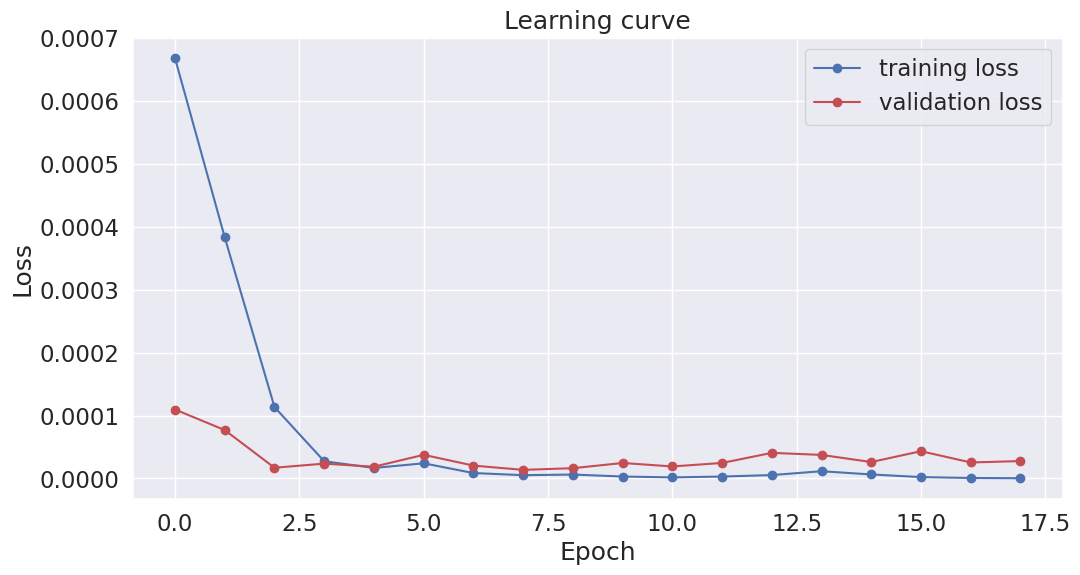

In [10]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## **Eval model**

In [11]:
print("1.1. Creating NER data // Test data")
dict_data_test = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_test = pd.DataFrame(list(dict_data_test.items()), columns=["archivo_origen", "Text"])

dict_ann_test = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_test = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test.items()])
# df_ann = None

data_prepared_test, all_attribute_labels_test, file_names_test, preparation_warnings_train, tokenizer_re = prepare_data_SYNC(data=df_data_train, data_ann=df_ann_train, entity_label="DISO", tokenizer=tokenizer_ner, w=2, print_warnings=False, return_tokenizer=True)

all_attribute_labels_test = remap_att_attribute_labels(all_attribute_labels_test, label2id={'O': 0, 'History_of': 1, 'Family_history_of': 2}, id2label={0: 'O', 1: 'History_of', 2: 'Family_history_of'}, outside_label="O", data_prepared=data_prepared_test)

1.1. Creating NER data // Test data


Preparing data for ATT prediction: Entities and marked contexts:   0%|          | 0/1268 [00:00<?, ?text/s]

In [12]:
aux = {}
for i in all_attribute_labels_test:
    for j in i:
        if j not in aux:
            aux[j] = 0
        aux[j] += 1
aux

{'O': 16306, 'History_of': 716, 'Family_history_of': 3}

In [13]:
id2label = read_json_single(ctx.paths.docs_dir / "ATTTraining/Status/id2label_status_attclassifier.json")
label2id = read_json_single(ctx.paths.docs_dir / "ATTTraining/Status/label2id_status_attclassifier.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}
dataset_full_test, data_loader_full_test, _, _ = construct_loader_att_SYNC(data_prepared_test, all_attribute_labels_test, 
                                                                        file_names=file_names_test, label2id=label2id, id2label=id2label, seed=SEED, batch_size=16)

modelo_att = initialize_att_model(ctx, model_ner, len(id2label), "ATTTraining/Status/status_attclassifier_checkpoint.pt")

In [ ]:
results = run_att_classifier_SYNC(modelo_att, data_loader=data_loader_full_test, device=ctx.device, id2label=id2label, train=False)

ATT / Inference:   0%|          | 0/1065 [00:00<?, ?batch/s]


Classification report:
                   precision    recall  f1-score   support

Family_history_of     0.6000    1.0000    0.7500         3
       History_of     0.7947    1.0000    0.8856       716
                O     1.0000    0.9885    0.9942     16306

         accuracy                         0.9890     17025
        macro avg     0.7982    0.9962    0.8766     17025
     weighted avg     0.9913    0.9890    0.9896     17025

